# 05. Coal Distances, Collisions, And Contact Data

This notebook introduces the geometry-query workflow you will need later in exercises and projects. The emphasis is practical: define objects, place them in the world, ask for distances, check whether they collide, and inspect the contact data when they overlap.

## What you should remember
- A collision library needs two ingredients: geometry and placement.
- Distance queries ask **how far apart** objects are.
- Collision queries ask **whether** objects overlap.
- Penetration/contact queries ask for overlap details such as penetration depth, contact normal, and contact position.
- We will explain GJK later in the course; here the goal is to become comfortable with the API.

In [1]:
# %%capture
# !pip install pin viser robot_descriptions numpy scipy matplotlib trimesh

import site
site.main()

In [2]:
%%capture
!wget -O coal_helpers.py https://raw.githubusercontent.com/Atarilab/colab_utils/refs/heads/main/coal_helpers.py
!wget -O viz.py https://raw.githubusercontent.com/Atarilab/colab_utils/refs/heads/main/viz.py
import coal_helpers
import viz

If the next cell gives an error restart the session to load the libraries (ctrl + m + .) or click runtime -> restart session. Then rerun the second and third codeblocks (do not rerun the first block!).

In [3]:
import time

import coal
import matplotlib.pyplot as plt
import numpy as np
import pinocchio as pin
import trimesh

from coal_helpers import coal_to_se3, make_transform, rotation_from_x_axis
from viz import PinNotebookViz, add_mesh_handle, create_server

server, share_url = create_server()
notebook_viz = PinNotebookViz(server)

print(f"Open the visualizer here: {share_url}")


╭────── viser (listening *:8082) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8082   │
│   Websocket │ ws://localhost:8082     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://python-servo.share.viser.studio

Open the visualizer here: https://python-servo.share.viser.studio


(viser) Connection opened (0, 1 total), 6 persistent messages

## Three different questions
- **Distance query:** “How far apart are the objects?”
- **Collision query:** “Are they overlapping?”
- **Penetration/contact query:** “If they overlap, what is the penetration depth, contact normal, and contact position?”

## Step 1: visualize the objects first
Start by looking at the geometry before asking any query. The objects are slightly transparent so the frames and contact markers are easier to read later.

In [4]:
server.scene.reset()
notebook_viz.frame_handles = {}

sphere = coal.Sphere(0.20)
box = coal.Box(0.40, 0.30, 0.30)
T_sphere = make_transform([0.0, 0.0, 0.0])
T_box = make_transform([0.90, 0.0, 0.0])

sphere_mesh_blue = trimesh.creation.icosphere(radius=0.20, subdivisions=3)
sphere_mesh_blue.visual.face_colors = [80, 170, 255, 140]

sphere_mesh_red = trimesh.creation.icosphere(radius=0.20, subdivisions=3)
sphere_mesh_red.visual.face_colors = [255, 90, 90, 150]

box_mesh = trimesh.creation.box(extents=(0.40, 0.30, 0.30))
box_mesh.visual.face_colors = [255, 170, 60, 110]

sphere_handle = add_mesh_handle(server, '/sphere', sphere_mesh_blue, coal_to_se3(T_sphere))
box_handle = add_mesh_handle(server, '/box', box_mesh, coal_to_se3(T_box))

notebook_viz.show_frame('world', pin.SE3.Identity(), axes_length=0.20)
notebook_viz.show_frame('sphere_center', coal_to_se3(T_sphere), axes_length=0.12)
notebook_viz.show_frame('box_center', coal_to_se3(T_box), axes_length=0.12)


FrameHandle(show_axes=True, axes_length=0.12, axes_radius=0.008, origin_radius=0.016, origin_color=(236, 236, 0), scale=1.0)

## Step 2: ask for the distance and the witness points
The distance query tells us how far apart the objects are. The witness points are the nearest points on each object. The frames below are oriented so that their `x`-axes point **out of** the corresponding object.

In [5]:
distance_request = coal.DistanceRequest()
distance_result = coal.DistanceResult()
distance_value = coal.distance(sphere, T_sphere, box, T_box, distance_request, distance_result)

witness_sphere = distance_result.getNearestPoint1()
witness_box = distance_result.getNearestPoint2()
normal_world = np.asarray(distance_result.normal)

notebook_viz.show_frame('witness_on_sphere', pin.SE3(rotation_from_x_axis(normal_world), witness_sphere), axes_length=0.10)
notebook_viz.show_frame('witness_on_box', pin.SE3(rotation_from_x_axis(-normal_world), witness_box), axes_length=0.10)

print('distance =', distance_value)
print('nearest point on sphere =', witness_sphere)
print('nearest point on box    =', witness_box)
print('distance normal         =', normal_world)

distance = 0.49999999999999994
nearest point on sphere = [0.2 0.  0. ]
nearest point on box    = [0.7 0.  0. ]
distance normal         = [1. 0. 0.]


## Step 3: move into collision and inspect the contact data
Now move the sphere so that it overlaps the box. The collision query tells us whether an overlap exists, and the contact data tells us where and how deeply the overlap happens. Again, the two frames at the contact point are oriented so that they point out of the sphere and out of the box respectively.

In [6]:
T_sphere_penetrating = make_transform([0.65, 0.0, 0.0])
sphere_handle.remove()
sphere_handle = add_mesh_handle(server, '/sphere', sphere_mesh_red, coal_to_se3(T_sphere_penetrating))

collision_request = coal.CollisionRequest()
collision_result = coal.CollisionResult()
num_contacts = coal.collide(sphere, T_sphere_penetrating, box, T_box, collision_request, collision_result)
contact = collision_result.getContact(0)

notebook_viz.show_frame('contact_on_sphere', pin.SE3(rotation_from_x_axis(contact.normal), contact.pos), axes_length=0.10)
notebook_viz.show_frame('contact_on_box', pin.SE3(rotation_from_x_axis(-contact.normal), contact.pos), axes_length=0.10)

print('number of contacts reported =', num_contacts)
print('is collision?               =', collision_result.isCollision())
print('contact position (world)    =', contact.pos)
print('contact normal (world)      =', contact.normal)
print('penetration depth           =', contact.penetration_depth)


number of contacts reported = 1
is collision?               = True
contact position (world)    = [0.775 0.    0.   ]
contact normal (world)      = [1. 0. 0.]
penetration depth           = -0.15000000000000008


## Step 4: sweep through different separations
This is a useful pattern in projects: move one object, update the query, and watch distance become collision and then penetration. The sphere turns red when a collision is active.

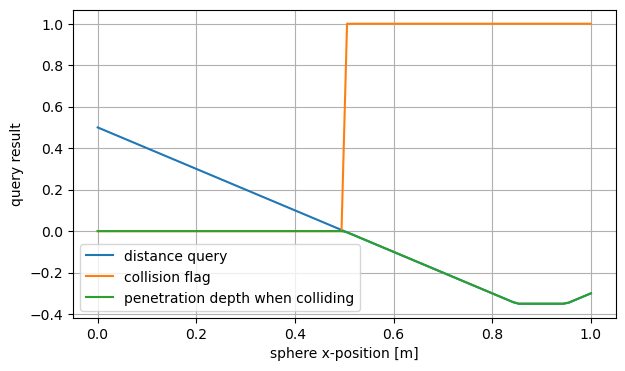

In [9]:
x_values = np.linspace(0.00, 1.00, 90)
distances = []
in_collision = []
penetration_depths = []

for x in x_values:
    T_current = make_transform([x, 0.0, 0.0])
    d_res = coal.DistanceResult()
    c_res = coal.CollisionResult()
    d = coal.distance(sphere, T_current, box, T_box, coal.DistanceRequest(), d_res)
    coal.collide(sphere, T_current, box, T_box, coal.CollisionRequest(), c_res)

    collision_active = c_res.isCollision()
    sphere_handle.remove()
    sphere_mesh = sphere_mesh_red if collision_active else sphere_mesh_blue
    sphere_handle = add_mesh_handle(server, '/sphere', sphere_mesh, coal_to_se3(T_current))
    notebook_viz.show_frame('sphere_center', coal_to_se3(T_current), axes_length=0.12)

    distances.append(d)
    in_collision.append(collision_active)
    if collision_active:
        current_contact = c_res.getContact(0)
        penetration_depths.append(current_contact.penetration_depth)
        notebook_viz.show_frame('point_on_sphere', pin.SE3(rotation_from_x_axis(current_contact.normal), current_contact.pos), axes_length=0.10)
        notebook_viz.show_frame('point_on_box', pin.SE3(rotation_from_x_axis(-current_contact.normal), current_contact.pos), axes_length=0.10)
    else:
        penetration_depths.append(0.0)
        current_normal = np.asarray(d_res.normal)
        notebook_viz.show_frame('point_on_sphere', pin.SE3(rotation_from_x_axis(current_normal), d_res.getNearestPoint1()), axes_length=0.10)
        notebook_viz.show_frame('point_on_box', pin.SE3(rotation_from_x_axis(-current_normal), d_res.getNearestPoint2()), axes_length=0.10)

    time.sleep(0.02)

plt.figure(figsize=(7, 4))
plt.plot(x_values, distances, label='distance query')
plt.plot(x_values, np.array(in_collision, dtype=float), label='collision flag')
plt.plot(x_values, penetration_depths, label='penetration depth when colliding')
plt.xlabel('sphere x-position [m]')
plt.ylabel('query result')
plt.grid(True)
plt.legend()
plt.show()


## Exercise: convert world-frame witness/contact data into local object coordinates
Coal gives witness points and contact positions in the world frame. Convert them into the local coordinates of the sphere and box using the object transform directly.

In [11]:
T_sphere_pin = coal_to_se3(T_sphere)
T_box_pin    = coal_to_se3(T_box)

contact_world = np.array(contact.pos)

# Transform into local object frame using inverse transform
contact_local_sphere = T_sphere_pin.inverse().act(contact_world)
contact_local_box    = T_box_pin.inverse().act(contact_world)